In [ ]:
tm ux lsimport sqlite3
import pandas as pd
import plotly.express as px
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
def plotids(selected_ids):
    import numpy as np
    import matplotlib.pyplot as plt
    import tables
    print(f"Selected {len(selected_ids)} points")
    n = min(len(selected_ids), 100)
    cols = 10
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 1.5 * rows))
    axes = np.array(axes).flat  # handles both 1-row and multi-row cases

    with tables.open_file("mitosis_train_patches.pytable", "r") as f:
        patches = f.root.patch[selected_ids[:n],::]
        labels = f.root.label_mdy[selected_ids[:n]]
        patch_ids = f.root.patch_id_unique[selected_ids[:n]]
        

    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(patches[i])
            ax.set_title(f"id:{patch_ids[i]}\nlbl:{labels[i]}", fontsize=6)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
# --- Load coordinates from SpatiaLite ---
conn = sqlite3.connect("coords_embeddings.db")
df  = pd.read_sql("SELECT id, x, y,emb FROM patches", conn)


In [4]:
df

,id,x,y,emb
0,0,76.061012,57.248127,b'K:\xf27K\xc6\x03>\xd3\xabb=p\xcf\xb2=!^[\xbd...
1,1,54.022682,30.395639,b'\xa1\xeeU:}\xd3O\xbeH\xed \xbe\x07\xd2\xe6\x...
2,2,38.175457,71.541992,b'N\xfd\x92:\x81eS=b\x1e\x11\xbe4Y\x9d;\x05\xd...
3,3,65.972084,22.882605,b'O\xd2\xdc9\x10\xe6H\xbe\xc2\xc9\xcb\xbde\xf6...
4,4,33.786522,30.860474,b'\xbe)\xcb;\xa5\x9e\x86\xbe\xd7E\x82\xbe0\xaa...
...,...,...,...,...
8943,8943,50.087852,20.713140,b'i\x8c\x1c9+\xab\x8d\xbe<\x83H\xbe\xc34&\xbe\...
8944,8944,23.051117,60.871006,b'\xcc\xb8\x8a:\xb3K\xbe\xbdR\xb9a\xbeX\xbc\xc...
8945,8945,24.655407,68.538078,"b""\x11\x12\x86:\xfc\x08\x01\xbd\xcb\xdfN\xbe\x..."
8946,8946,65.189728,65.013512,b'\x13~e:HI\r>\xa8\x10\xc8;\xe4;\xb0=\xac\x83\...


In [5]:
import tables
with tables.open_file("mitosis_train_patches.pytable", "r") as f:
    all_labels = f.root.label_mdy[:]
    scanner = f.root.scanner[:]
    

In [6]:
#----

In [7]:
import os, sqlite_vector
conn.enable_load_extension(True)
so_path = os.path.join(os.path.dirname(sqlite_vector.__file__), "binaries", "vector")
conn.load_extension(so_path)


In [8]:
# -- Initialize the vector. By default, the distance function is L2.
# -- To use a different metric, specify one of the following options:
# -- distance=L1, distance=COSINE, distance=DOT, distance=SQUARED_L2, or distance=HAMMING.
# SELECT vector_init('images', 'embedding', 'type=FLOAT32,dimension=384');
conn.execute("SELECT vector_init('patches', 'emb', 'type=FLOAT32,dimension=16,distance=COSINE')")

In [9]:
# import numpy as np
# df["x"] = np.random.rand(len(df))
# df["y"] = np.random.rand(len(df))


In [10]:
df["x"]

0       76.061012
1       54.022682
2       38.175457
3       65.972084
4       33.786522
          ...    
8943    50.087852
8944    23.051117
8945    24.655407
8946    65.189728
8947    45.110783
Name: x, Length: 8948, dtype: float64

In [12]:
import plotly.graph_objs as go

fw = go.FigureWidget(data=go.Scatter(
    x=df["x"], y=df["y"],
    mode="markers",
    customdata=df["id"],
))
fw.layout.dragmode = "lasso"

selected_ids = []

def on_select(trace, points, selector):
    selected_ids.clear()
    selected_ids.extend([trace.customdata[i] for i in points.point_inds])
    print(f"Selected {len(selected_ids)} points")

fw.data[0].on_selection(on_select)
fw

FigureWidget({
    'data': [{'customdata': array([   0,    1,    2, ..., 8945, 8946, 8947], shape=(8948,)),
              'mode': 'markers',
              'type': 'scatter',
              'uid': 'b4ffe8ec-0a93-46b8-a356-086f31915c41',
              'x': array([76.06101227, 54.02268219, 38.175457  , ..., 24.65540695, 65.18972778,
                          45.11078262], shape=(8948,)),
              'y': array([57.24812698, 30.39563942, 71.54199219, ..., 68.53807831, 65.01351166,
                          67.79908752], shape=(8948,))}],
    'layout': {'dragmode': 'lasso', 'template': '...'}
})

In [16]:
len(selected_ids)


92

Selected 92 points


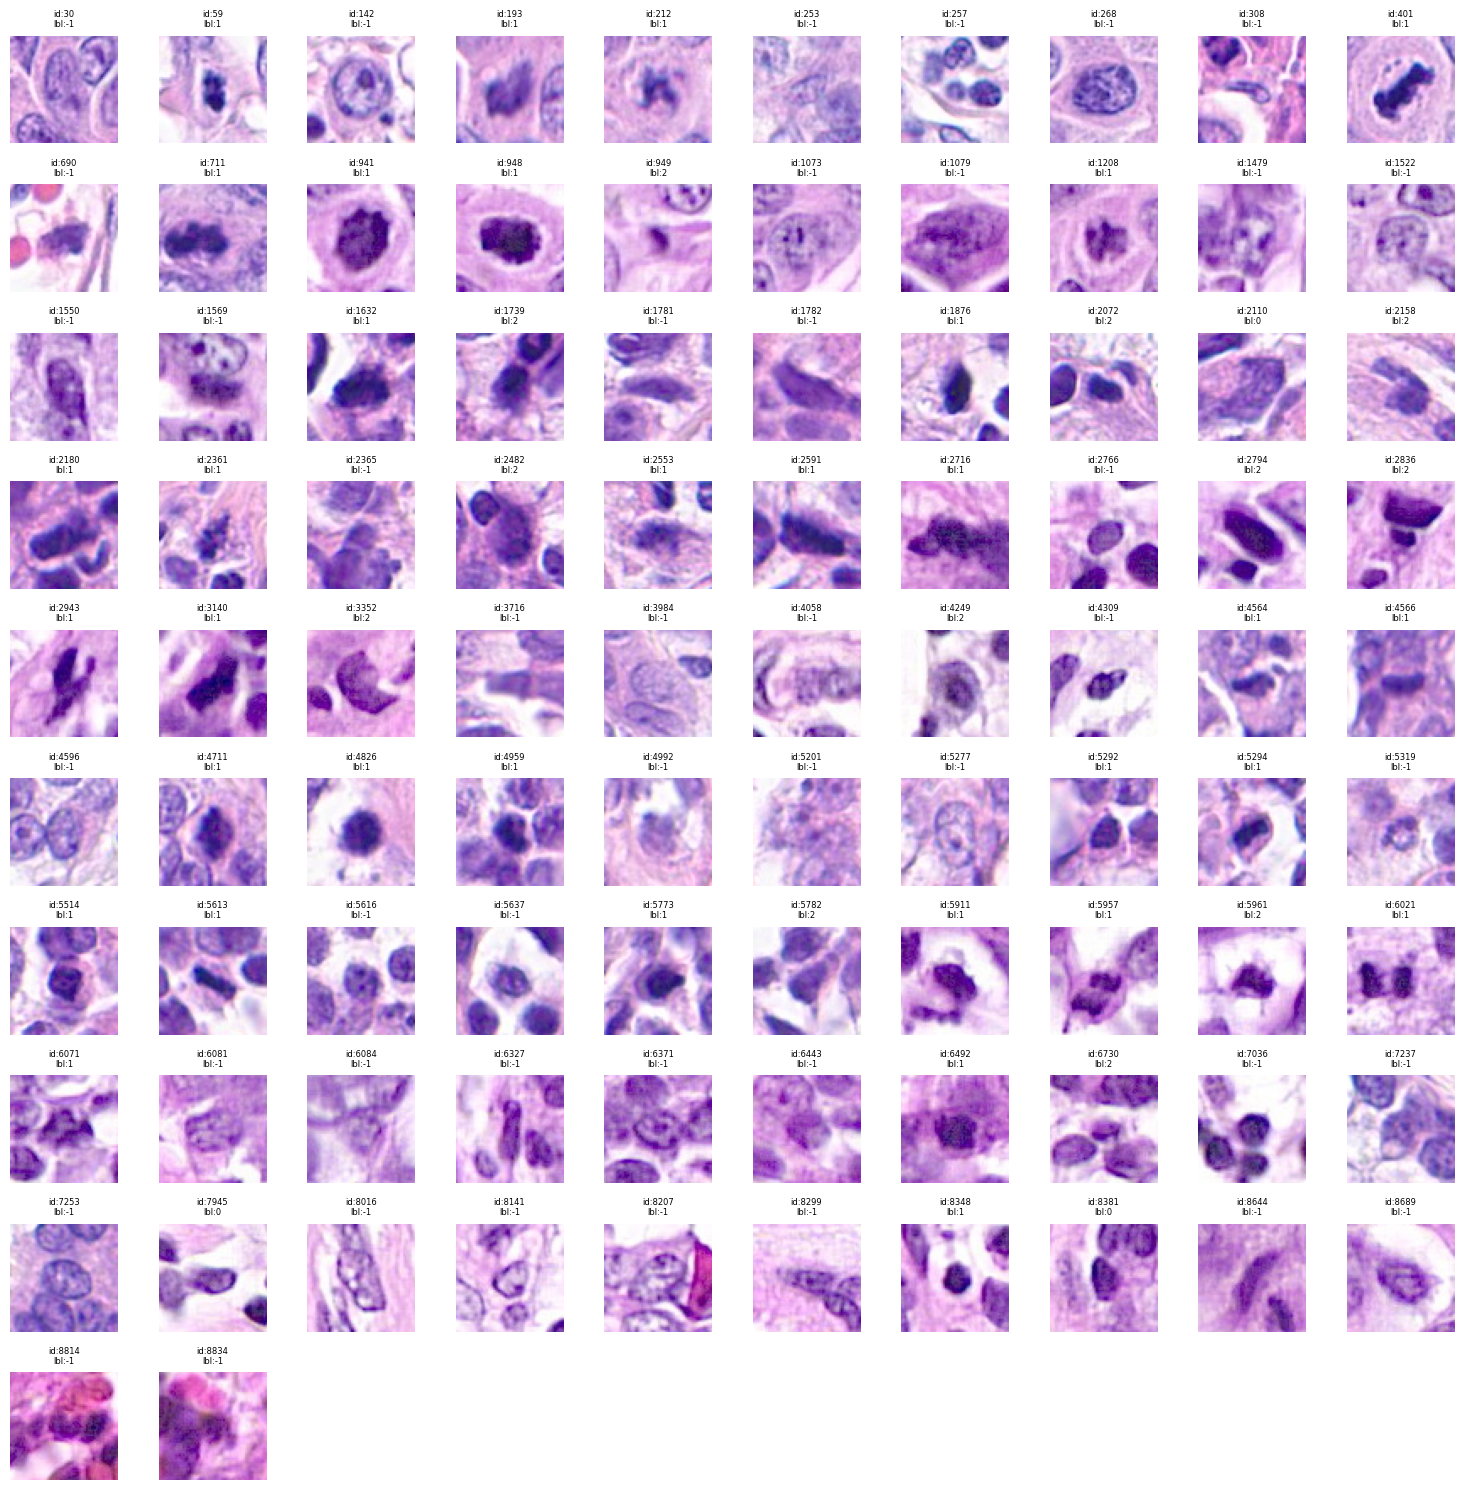

In [17]:
plotids(selected_ids)


In [ ]:
#--- high dimensional search

In [18]:
%%time
def query_vector(mean_emb):
    query_blob = sqlite3.Binary(mean_emb.tobytes())
    results = conn.execute("""
        SELECT p.id, v.distance
        FROM patches AS p
        JOIN vector_full_scan('patches', 'emb', ?) AS v ON p.id = v.rowid
        ORDER BY v.distance
        LIMIT 100
    """, (query_blob,)).fetchall()
    ids, distances = zip(*results)
    print(results[0:5])
    return list(ids), list(distances)
def query_id(id):
    results = conn.execute("""
        SELECT emb 
        FROM patches where id = ?
        """, (int(id),)).fetchall()

    query_vec = np.frombuffer(results[0][0], dtype=np.float32)
    return query_vector(query_vec)
    # results = conn.execute("""
    #     SELECT emb, 
    #     FROM patches AS where id = ?
    # """, (id,)).fetchall()

    # query_vec = np.frombuffer(df.loc[id, "emb"], dtype=np.float32)
    # return query_vector(query_vec)


CPU times: user 23 μs, sys: 0 ns, total: 23 μs
Wall time: 50.3 μs


In [19]:
import numpy as np
embs = np.stack([np.frombuffer(e, dtype=np.float32) for e in df.loc[selected_ids, "emb"]])
mean_emb = embs.mean(axis=0)
results = query_vector(mean_emb)

[(5680, 9.071826934814453e-05), (2413, 0.00010758638381958008), (4317, 0.00013387203216552734), (2615, 0.0001348257064819336), (2830, 0.00013488531112670898)]


In [20]:
# --- quantization --- but would focus on full reprensetations first. be ware, need to check that the results are meaningful  with q=2 + 4 the results were very suboptimal
# #-- seutp quantization (for faster search, with some loss in accuracy)
# conn.execute("SELECT vector_quantize('patches', 'emb', 'qtype=TURBO,qbits=4');")
# ##-- Optional preload quantized version in memory (for a 4x/5x speedup) 
# conn.execute("SELECT vector_quantize_preload('patches', 'emb');")
# %%time
# query_blob = sqlite3.Binary(mean_emb.tobytes())
# results = conn.execute("""
#     SELECT p.id, v.distance
#     FROM patches AS p
#     JOIN vector_quantize_scan('patches', 'emb', ?) AS v ON p.id = v.rowid
#     ORDER BY v.distance
#     LIMIT 100
# """, (query_blob,)).fetchall()

# top_ids = [r[0] for r in results]
# #print(top_ids[:5])
# print(results[0:5])



In [21]:
##sanity check
print(np.frombuffer(df.loc[results[0][0],"emb"],dtype=np.float32))
print(mean_emb)

[ 0.00209215 -0.07149649 -0.15625277 -0.04744319 -0.00427395 -0.04127374
 -0.0493044   0.0785386  -0.05864608 -0.05181848  0.09015007 -0.0925496
  0.02610517  0.03064109  0.10623194 -0.96029913]
[ 0.0013418  -0.15549104 -0.07678272 -0.0760583   0.11285691  0.17464167
 -0.0240002  -0.07684034 -0.21438918 -0.18802191 -0.1603852  -0.01864705
 -0.05759561 -0.02076444 -0.16267797 -0.8800227 ]


Selected 100 points


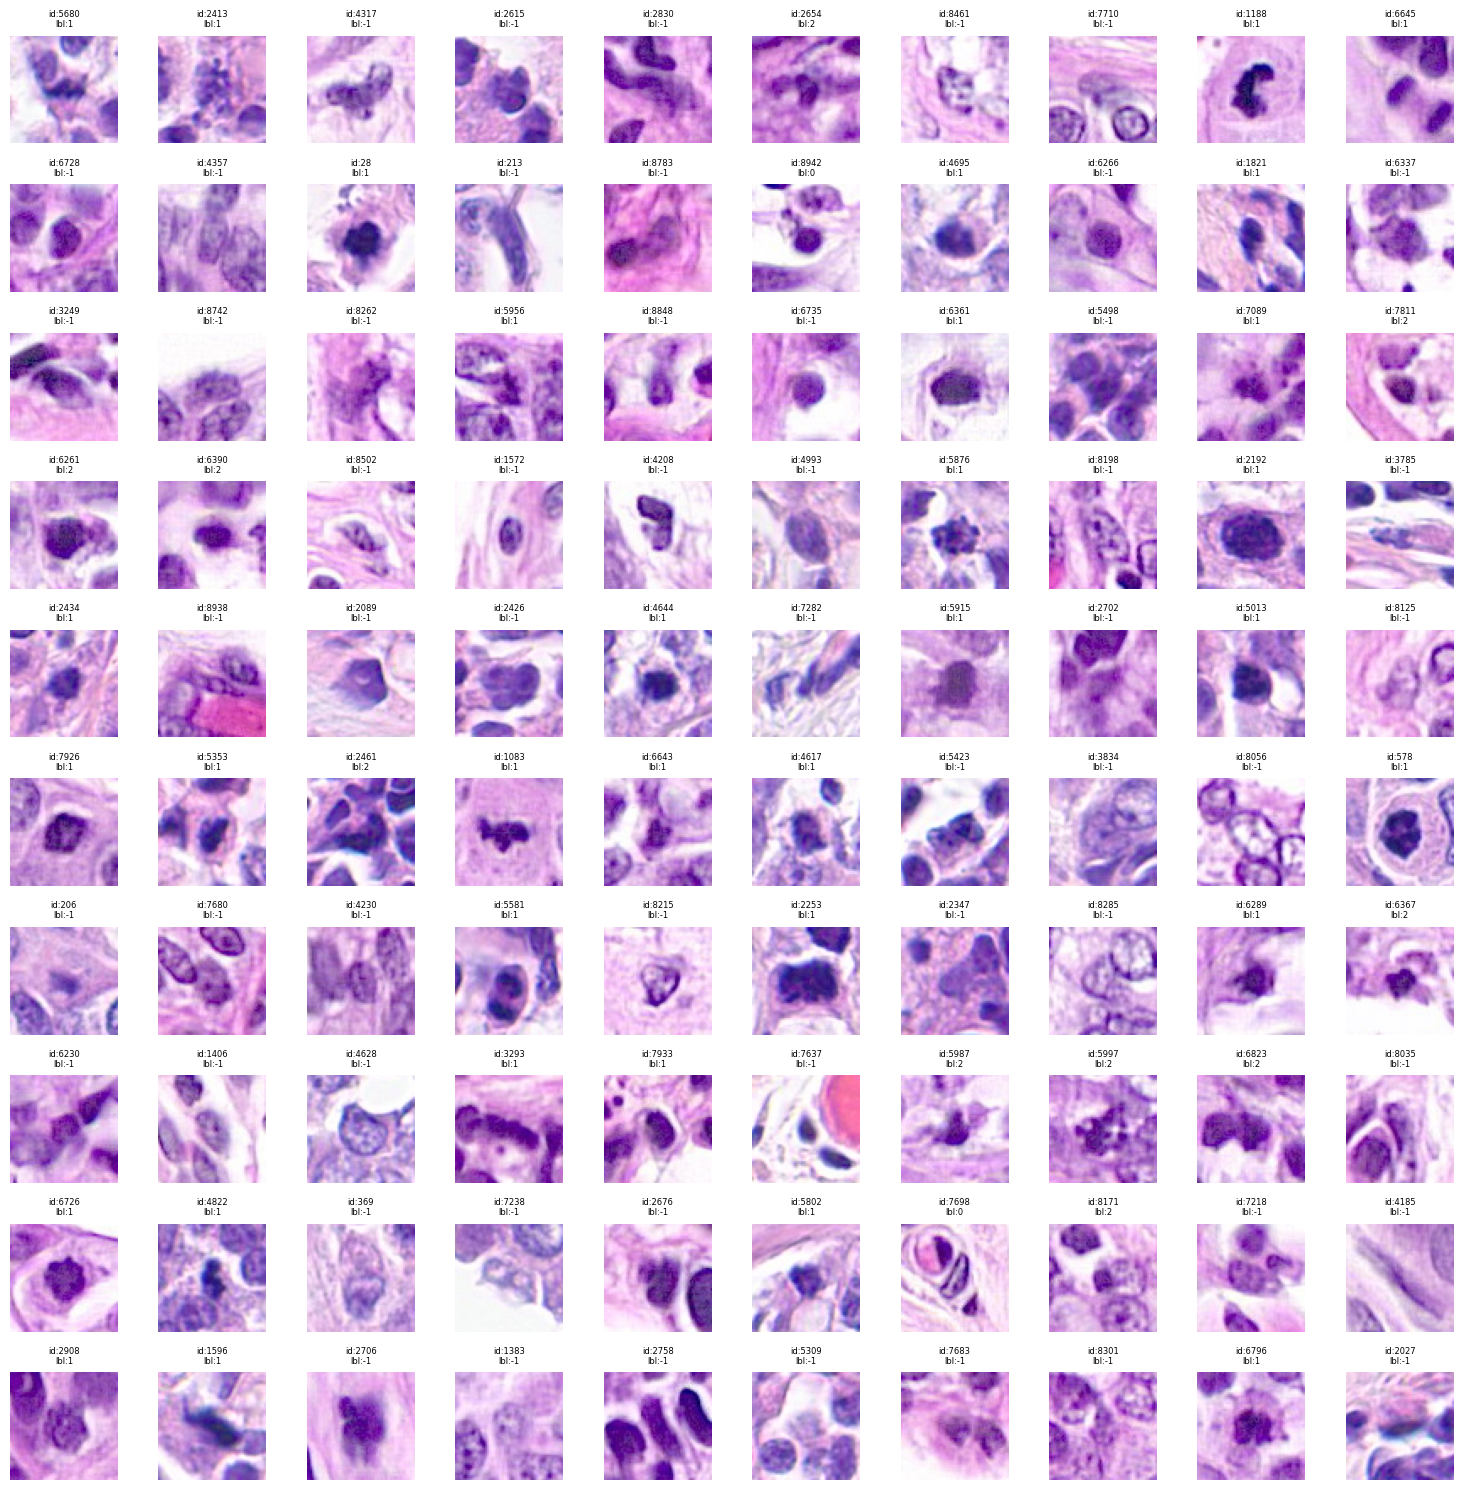

In [22]:
plotids(results[0])

Selected 1 points


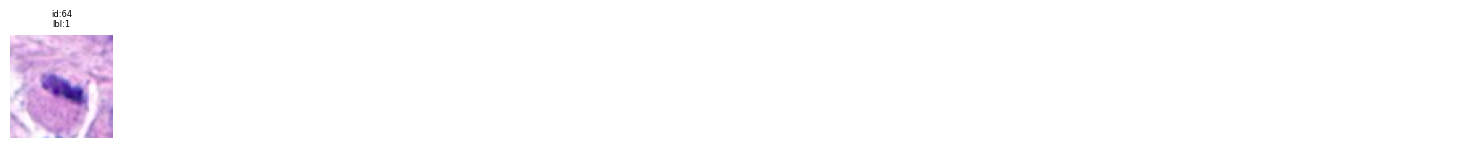

In [23]:
plotids([64])

In [ ]:
plotids((all_labels==1).nonzero()[0])

133
[(133, 0.0), (6871, 2.384185791015625e-06), (17, 2.2411346435546875e-05), (8492, 3.165006637573242e-05), (6333, 4.3392181396484375e-05)]
Selected 10 points


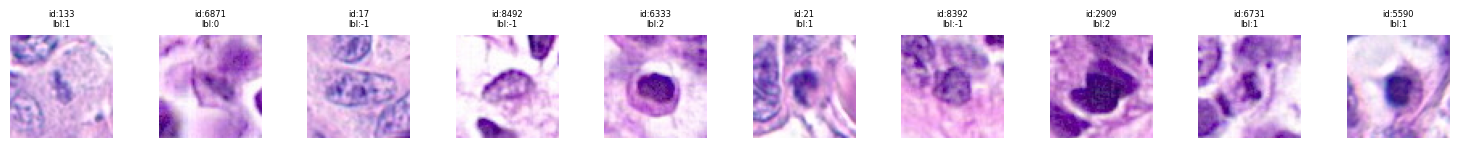

In [25]:
import numpy as np
posids=(all_labels==1).nonzero()[0]
pid=64
print(posids[pid])
plotids(query_id(posids[pid])[0][0:10])

In [ ]:
plotids(query_id(64)[0])

In [ ]:
import numpy as np
posids=(all_labels==1).nonzero()[0]
for pid in range(10):
    print(posids[pid])
    plotids(query_id(posids[pid])[0][0:10])

In [ ]:
plotids(query_id(352)[0][0:20])

In [ ]:
import numpy as np
negids=(all_labels==0).nonzero()[0]
for nid in range(30):
    print(negids[nid])
    plotids(query_id(negids[nid])[0][0:10])

In [ ]:
def plot_scatter(df, all_labels):
    import matplotlib.pyplot as plt
    import numpy as np

    x = df["x"].values
    y = df["y"].values
    labels = np.array(all_labels)

    unique_labels = np.unique(labels)
    color_map = {
        label: plt.cm.tab20(i / len(unique_labels))
        for i, label in enumerate(unique_labels)
    }

    plt.figure(figsize=(6, 5))

    for label in unique_labels:
        idx = labels == label
        plt.scatter(x[idx], y[idx], label=label, s=5)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()
plot_scatter(df, all_labels)

In [ ]:
plot_scatter(df[(all_labels == 0) | (all_labels == 1)], all_labels[(all_labels == 0) | (all_labels == 1)])

In [ ]:
import numpy as np

def knn_purity_for_id(id, k=10):
    ids, _ = query_id(id)   # full KNN retrieval

    # take top-k
    nn_ids = np.array(ids[:k])

    nn_labels = np.array(all_labels[nn_ids])

    # filter only {0,1}
    #mask = (nn_labels == 0) | (nn_labels == 1)
    filtered = nn_labels[mask]

    if len(filtered) == 0:
        return np.nan  # or 0, depending on convention

    return np.mean(filtered == 1)


pos_ids = np.where(all_labels == 1)[0]

purities = []
for i in pos_ids:
    purities.append(knn_purity_for_id(i, k=20))

purities = np.array(purities)

In [ ]:
purities.mean()

In [ ]:
plt.hist(purities)

In [ ]:
def plot_scatter(df, all_labels):
    import matplotlib.pyplot as plt
    import numpy as np

    x = df["x"].values
    y = df["y"].values
    labels = np.array(all_labels)

    unique_labels = np.unique(labels)
    color_map = {
        label: plt.cm.tab20(i / len(unique_labels))
        for i, label in enumerate(unique_labels)
    }

    plt.figure(figsize=(6, 5))

    for label in unique_labels:
        idx = labels == label
        plt.scatter(x[idx], y[idx], label=label, s=20)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


 
plot_scatter(df, scanner)


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

# ------------------------------------------------------------
# Keep only labels 0 and 1
# ------------------------------------------------------------

valid_mask = np.isin(all_labels, [0, 1])

ids = np.where(valid_mask)[0]
y = all_labels[ids]

print(f"{len(ids)} samples")
print(f"class balance: {np.bincount(y)}")

# ------------------------------------------------------------
# Determine embedding dimension automatically
# ------------------------------------------------------------

first_blob = conn.execute(
    "SELECT emb FROM patches WHERE id = ?",
    (int(ids[0]),)
).fetchone()[0]

dim = len(np.frombuffer(first_blob, dtype=np.float32))

print(f"Embedding dimension: {dim}")

# ------------------------------------------------------------
# Load embeddings
# ------------------------------------------------------------

X = np.empty((len(ids), dim), dtype=np.float32)

for i, pid in enumerate(ids):
    emb_blob = conn.execute(
        "SELECT emb FROM patches WHERE id = ?",
        (int(pid),)
    ).fetchone()[0]

    X[i] = np.frombuffer(emb_blob, dtype=np.float32)

print("X shape:", X.shape)


In [ ]:
# ------------------------------------------------------------
# Stratified 5-fold CV
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_true = []
all_pred = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    clf = RandomForestClassifier(
        n_estimators=500,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42,
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print("\n" + "=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)
    print(classification_report(y_test, y_pred, digits=4))

    all_true.extend(y_test)
    all_pred.extend(y_pred)

# ------------------------------------------------------------
# Overall performance
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("OVERALL")
print("=" * 60)

print(
    classification_report(
        all_true,
        all_pred,
        digits=4
    )
)

In [ ]:
from collections import Counter
Counter(all_labels)